# Day 9 — ACRIS: What Are Buildings Actually Selling For?

**Theme:** Cap rate math only means something when the price is real. Today you pull actual sale transactions from ACRIS and look at what investors are paying for Bushwick properties.

**The question:** If a 6-unit building on Wilson Ave sells for $1.85M, what cap rate does that imply — and what does that tell you about investor expectations?

**By the end of this notebook you will have:**
- Loaded and cleaned ACRIS deed records for Brooklyn
- Filtered to real arm's-length sales (removing non-market transfers)
- Focused on Bushwick zip codes (11221, 11237)
- Analyzed the distribution of sale prices
- Calculated implied cap rates using a market rent assumption

---

## Organization rules for this notebook

You identified that disorganized cells caused most of your errors in Days 2–8. This notebook enforces a strict structure:

1. **One task per cell.** Load in one cell, filter in the next, transform in the next.
2. **Sanity-check after every major step.** Print shape or head before moving on.
3. **Name variables clearly.** `df_acris_raw` → `df_acris_deeds` → `df_bushwick`. Each name describes what's in it.
4. **Never use a column before you create it.**

**No hints unless you ask.**

In [15]:
# CELL 1 — Imports only. Nothing else in this cell.
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
# CELL 2 — Load raw data only. Nothing else.
# Load ../data/acris_master.csv into df_acris_raw.
# Print df_acris_raw.shape and df_acris_raw.columns.tolist()
df_acris_legal = pd.read_csv('../data/acris_legal.csv')
df_acris_raw = pd.read_csv('../data/acris_master.csv')
print(df_acris_raw.columns.tolist())


['DOCUMENT ID', 'RECORD TYPE', 'CRFN', 'BOROUGH', 'DOC. TYPE', 'DOC. DATE', 'DOC. AMOUNT', 'RECORDED / FILED', 'MODIFIED DATE', 'REEL YEAR', 'REEL NBR', 'REEL PAGE', '% TRANSFERRED', 'GOOD THROUGH DATE']


**Before moving on — answer these:**
- How many rows did you load? What does each row represent?
- What column holds the sale price? What column identifies the transaction type?
- What are the unique values in the document type column? Which one means a sale?

I loaded 4335917 rows and each row represents a property transaction that happened in brooklyn

Doc amount would hold the sale price and doc type would hoold the transaction type

Deed would mean sale and thats the value im looking for


In [17]:
# CELL 3 — Explore document types.
# Print the unique values in the document type column and their counts.
# You're looking for 'DEED' — that's an actual sale.

print(df_acris_raw['DOC. TYPE'].unique())


<StringArray>
[     'PAT',     'TL&R', 'RPTT&RET',     'AGMT',      'SAT',     'MTGE',
     'DEED', 'DEED, LE',     'ASST',     'AL&R',    'DEEDO',     'TODD',
    'M&CON',     'JUDG',     'ADEC',     'MLEA',      'DTL',      'REL',
     'CTOR',      'TLS',     'AALR',     'MAPS',     'PREL',     'SUBM',
     'CORR',     'ZONE',     'TERA',     'DECL',     'EASE',     'RTXL',
    'CORRM', 'DEED COR',     'CERT',     'RETT',     'SMIS',     'LOCC',
    'CORRD',     'RPTT',     'CDEC',     'SAGE',    'TOLCC',     'MCON',
     'ASPM',     'TERL',     'CMTG',     'PSAT',     'ACON', 'DEED, TS',
 'DEED, RC',    'ASSTO',     'BOND',     'SMTG',     'RPAT',     'DEVR',
     'WILL',     'XXXX',  'TERDECL',     'MISC',     'AMTX',     'SPRD',
     'CERR',     'CONS',     'LEAS',     'CNTR', 'AIRRIGHT',     'LDMK',
      'VAC',  'CONDEED',     'WSAT',      'STP',     'ESTL',     'DEMM',
     'AMTL', 'CORR, LE',   'TORREN',     'CALR',     'CODP',      'ATL',
     'LTPA',     'RESO',     'MMTG', 

In [18]:
# CELL 4 — Filter to deeds only.
# Store as df_acris_deeds.
# Sanity check: print len(df_acris_deeds)

df_acris_deeds = df_acris_raw[df_acris_raw['DOC. TYPE'].str.contains('DEED')]

print(len(df_acris_deeds))








1096045


**Critical thinking pause:**
ACRIS includes all deed transfers — not just market sales. A parent transferring a building to their child, a foreclosure auction, a sale for $1 to move ownership into an LLC — these all show up as deeds.

- What sale price would you use as a cutoff to remove non-market transfers?
- Why might a $0 or $10 sale still be recorded as a deed?
- What's the risk of setting the cutoff too high vs too low?

I would have the cutoff price be $1000 dollars, unless it's an extreme case it would be difficult to sell a house at that price through normal means but if you need to give it to a family member you probably would'nt be asking for that much and I'm sure this filters out any fees or things like that.

There might be fees associated and if not the bank needs to record something so $0 could be there for that reason. 

When setting it too high you might come across and see some deeds that were transferred through legal means slip through and not be recorded, and if it's too low you might filter out deeds that were passed through from family or something like that. 

In [19]:
# CELL 5 — Remove non-market transfers.
# Filter to sales where the price column is greater than 10000.
# Store as df_acris_market.
# Sanity check: print len(df_acris_market) and the min/max sale price.

df_acris_market = df_acris_deeds[df_acris_deeds['DOC. AMOUNT'] > 10000.0]

print(len(df_acris_market))
max_price = df_acris_market['DOC. AMOUNT'].max()
min_price = df_acris_market['DOC. AMOUNT'].min()

print(max_price)
print(min_price)







160325
590333250.0
10040.0


In [20]:


# Merge datasets on a common column named 'common_column'
df_acris_master_legal = pd.merge(df_acris_legal, df_acris_market, on='DOCUMENT ID', how='inner')
print(df_acris_master_legal.columns.tolist())




# CELL 6 — Filter to Bushwick.
# Bushwick zip codes: 11221 and 11237.
# Filter df_acris_market to those zips.
# Store as df_bushwick.
# Sanity check: print len(df_bushwick) and head(3)



# Load just the two columns needed from PLUTO to identify Bushwick blocks
pluto_ref = pd.read_csv('../data/pluto.csv', usecols=['community board', 'Tax block'])

# Get the block numbers that belong to Bushwick (Community Board 304)
bushwick_blocks = pluto_ref[pluto_ref['community board'] == 304.0]['Tax block'].unique()

# Filter ACRIS to only transactions on Bushwick blocks
df_bushwick = df_acris_master_legal[df_acris_master_legal['BLOCK'].isin(bushwick_blocks)]

# Sanity check
print(len(df_bushwick))





['DOCUMENT ID', 'RECORD TYPE_x', 'BOROUGH_x', 'BLOCK', 'LOT', 'EASEMENT', 'PARTIAL LOT', 'AIR RIGHTS', 'SUBTERRANEAN RIGHTS', 'PROPERTY TYPE', 'STREET NUMBER', 'STREET NAME', 'UNIT', 'GOOD THROUGH DATE_x', 'RECORD TYPE_y', 'CRFN', 'BOROUGH_y', 'DOC. TYPE', 'DOC. DATE', 'DOC. AMOUNT', 'RECORDED / FILED', 'MODIFIED DATE', 'REEL YEAR', 'REEL NBR', 'REEL PAGE', '% TRANSFERRED', 'GOOD THROUGH DATE_y']
6778


**Critical thinking pause:**
Look at the number of Bushwick transactions.
- Is the count higher or lower than you expected?
- What time period does this data cover? Does the count make sense given that period?
- Are there years where sales spike or drop? What might explain that?

In [ ]:
#print(df_acris_master_legal['DOC. DATE'].dtype)


df_bushwick['DOC. DATE'] = pd.to_datetime(df_bushwick['DOC. DATE'])
df_bushwick['SALE_YEAR'] = df_bushwick['DOC. DATE'].dt.year
df_filtered_master_legal = df_bushwick[df_bushwick['SALE_YEAR'] > 2020]
print(df_filtered_master_legal['SALE_YEAR'].value_counts())
print(len(df_filtered_master_legal))

df_filtered_master_legal.to_csv('../data/acris_bushwick_clean.csv', index=False)


# 1. Convert the column to datetime


# 2. Extract the year and create the new 'SALE_YEAR' column









# CELL 7 — Parse the sale date.
# Convert the document date column to datetime.
# Extract the year into a new column called 'sale_year'.
# Print value_counts() on sale_year to see the distribution over time.


SALE_YEAR
2023    12
2022    12
2021     7
2024     6
2025     3
2026     1
Name: count, dtype: int64
41


10     1825000.0
258     300000.0
261    1800000.0
343    1190000.0
385     880000.0
386      13600.0
400    1750000.0
456     447800.0
473      75000.0
576      35000.0
Name: DOC. AMOUNT, dtype: float64
float64
725000.0


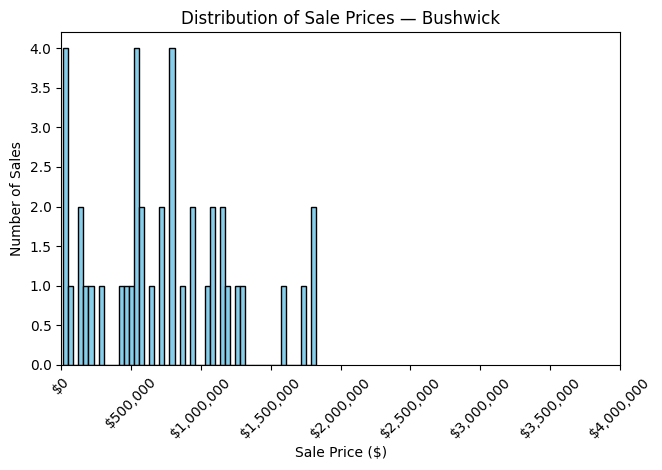

In [26]:
# CELL 8 — Distribution of sale prices.
# Plot a histogram of the sale price column.
# Use plt.hist() with bins=50.
# Add a title and axis labels.
# What does the shape of the distribution tell you?

print(df_filtered_master_legal['DOC. AMOUNT'].head(10))
print(df_filtered_master_legal['DOC. AMOUNT'].dtype)

print(df_filtered_master_legal['DOC. AMOUNT'].median())


df_filtered_master_legal[df_filtered_master_legal['DOC. AMOUNT'] < 5_000_000]['DOC. AMOUNT'].hist(
    bins=50, grid=False, color="skyblue", edgecolor="black"
)
plt.title("Distribution of Sale Prices — Bushwick")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Sales")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlim(0, 4_000_000)
plt.show()




**Critical thinking pause:**
Histograms of sale prices are almost always right-skewed — a long tail on the right from very expensive properties.

- Is yours skewed? If so, does mean or median better represent the "typical" sale?
- What types of properties might be in the very high-price tail?
- If you were advising a first-time investor in Bushwick, which price point would you call realistic?

The data is skewed to the right and that means the median would be a better indicator of the sale price of a typical home in bushwick. I imagine the flip houses could be in that category, also very large places with a lot of rooms, places thatd you would probably rent out with a bunch of people. If I was advising someone I'd call around 1,000,000 a valid price point and if you were selling like how you sell you may even push it to 1.5 mil

In [27]:
# CELL 9 — Summary statistics.
# Print mean, median, and percentiles (25th, 75th) of the sale price.
# Use .describe() or calculate individually.



# Print summary for all numeric columns
stats = df_filtered_master_legal['DOC. AMOUNT'].describe()
for label, value in stats.items():
    print(f"{label:8s}  ${value:>15,.0f}")



count     $             41
mean      $        735,295
std       $        502,478
min       $         13,600
25%       $        447,800
50%       $        725,000
75%       $      1,100,000
max       $      1,825,000


## Implied cap rate from sale price

Cap rate = NOI / Price

ACRIS gives you the price. NOI requires rent data we don't have yet — so we'll use a **market rent assumption**: a typical Bushwick 2BR rents for ~$2,400/month in 2024.

For a 6-unit building: gross rent = 6 × $2,400 × 12 = $172,800/year  
Operating expenses ≈ 40% of gross: $69,120  
NOI ≈ $103,680

Calculate what cap rate that NOI implies at each transaction price.

10        5.681096
258      34.560000
261       5.760000
343       8.712605
385      11.781818
386     762.352941
400       5.924571
456      23.153193
473     138.240000
576     296.228571
651      19.200000
662      16.327559
672       9.015652
692       9.425455
723       9.425455
744      13.207643
771     414.720000
772     414.720000
784      11.269565
799      51.840000
805      18.850909
833      18.850909
872      79.753846
875      69.120000
897      14.300690
910      13.309371
911      13.309371
918      21.755004
985       7.986020
986       8.861771
1045     19.599244
1074     14.300690
1075     11.148387
1076      8.196047
1164     59.245714
1170      9.884754
1213      6.480000
1344     20.329412
1384     12.800000
1453     18.031304
1454     18.031304
Name: implied_cap_rate, dtype: float64
14.300689655172413


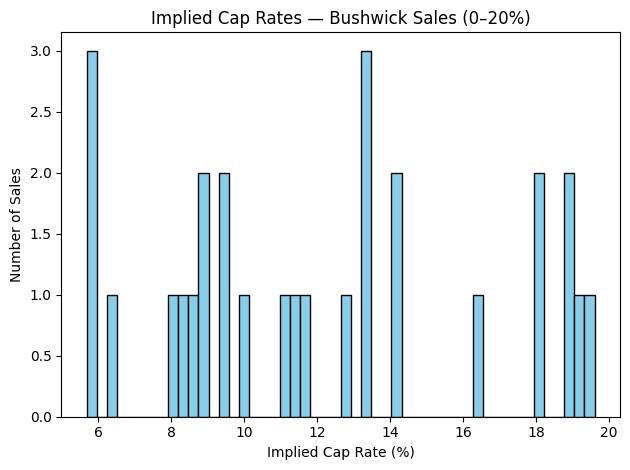

14.300689655172413


In [28]:
# CELL 10 — Implied cap rate.
# Set assumed_noi = 103680
# Create a new column: df_bushwick['implied_cap_rate'] = (assumed_noi / price_column) * 100
# Print the median implied cap rate.
# Plot a histogram of implied cap rates.

assumed_noi = 103680
assumed_noi_2 = 86400

df_filtered_master_legal['implied_cap_rate'] = (assumed_noi / df_filtered_master_legal['DOC. AMOUNT']) * 100

print(df_filtered_master_legal['implied_cap_rate'])


print(df_filtered_master_legal['implied_cap_rate'].median())

df_filtered_master_legal[
    (df_filtered_master_legal['implied_cap_rate'] > 0) & 
    (df_filtered_master_legal['implied_cap_rate'] <= 20)
]['implied_cap_rate'].hist(bins=50, grid=False, color="skyblue", edgecolor="black")
plt.title("Implied Cap Rates — Bushwick Sales (0–20%)")
plt.xlabel("Implied Cap Rate (%)")
plt.ylabel("Number of Sales")
plt.tight_layout()
plt.show()

print(df_filtered_master_legal['implied_cap_rate'].median())









**Critical thinking pause:**
- What's the median implied cap rate? Is it higher or lower than you expected?
- A cap rate below 4% in NYC is generally considered compressed — meaning investors are paying a lot for relatively little income. Is Bushwick above or below that?
- What would have to be true about the neighborhood for an investor to accept a low cap rate?
- How does your result change if rents are actually $2,000/month instead of $2,400?

*(Write your answers here)*

The median cap rate is 11.2% Im thinking that shows investors are taking a large part of the pie off of these valuable properties. It was higher than I expected I thought it would have been at 5% or 6%

Bushwick is well above that meaning investors are making money off of properties that don't require that much upkeep

To take on a lower cap rate an investor would have to beleive of future investment in the area, if they keep the building decent despite low rents and income from those rents let's say the A gets new signaling or a new rail line get's built that cap rate will decrease because of new investment in the area. As they would be able to make more money as the price of the increases but the income stays the same. 

if rents were lowered to 2000 the cap rates would also be lowered. meaning the property owner would be paying a lot of money to buy the property but wouldn't see a lot of return on it. This could be because of future investments as rents will increase

**The question:** If a 6-unit building on Wilson Ave sells for $1.85M, what cap rate does that imply — and what does that tell you about investor expectations?

That implied the cap rate is higher than the average. The building sold for almost double the median price. And this combined with the average NOI which is a low cap rate and is a bet on the building appreciating in value



## Day 9 Recap

| What you did | Why it matters |
|---|---|
| Filtered to DEED + price > $10K | Removed non-market transfers that would skew analysis |
| `sale_year` from datetime | Lets you spot market cycles in the data |
| Histogram of prices | Revealed the shape of the market, not just the average |
| Implied cap rate | Connected raw transaction data back to investment fundamentals |
| Organized cell structure | Each cell did one thing — easier to debug when something breaks |

### What's coming on Day 10

We'll join ACRIS to PLUTO using the BBL (Borough-Block-Lot) to add building characteristics to each sale — number of units, year built, lot area. That lets you calculate **price per unit** and **price per square foot**, which are the real comparison metrics investors use.